---

# First EDA on Dummy Data

---

**Project:** ELFI - Emotional & Latent Feedback Interpretation
**Data:** 500 synthetic responses to a German employee survey (54 Likert items + 1 free-text question)

> The interpreted results of this notebook are collected in **[findings.md](findings.md)**.
> This notebook contains the analysis; findings.md contains the conclusions.


---

## Setup

---


In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk import tokenize

from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud

from data_profiling import ProfileReport


In [2]:
# Download the required NLTK resources quietly

# Punkt sentence tokenizer (needed for tokenize.sent_tokenize further below)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

# German stopword list (needed for the n-gram analysis of the free-text answers)
nltk.download('stopwords', quiet=True)


True

In [3]:
# Render plots inline in the notebook.
# ipykernel activates this automatically in most setups, but stating it
# explicitly makes the notebook behave the same in every environment.
%matplotlib inline

# Suppress warning messages to keep the output clean
import warnings
warnings.filterwarnings('ignore')

# Set the background style of the plots to a white grid
sns.set_style('whitegrid')

# Set the default size for all plots (width: 17, height: 7)
plt.rcParams['figure.figsize'] = (17, 7)


---

## Loading Data & First Cleaning

---


In [4]:
# Read in the raw data (CSV export of the survey tool)
df_raw = pd.read_csv('data/synthetic_employee_survey_500_same_structure.csv')

# Keep df_raw untouched as a reference and work on a copy.
# Every cleaning step below overwrites `data` in place, so without this split a
# re-run from the middle of the notebook would silently work on already
# processed data.
data = df_raw.copy()

# First preview (first 5 rows)
display(data.head())

# Check structure and data types (null values, column names)
data.info()


,ID,Startzeit,Fertigstellungszeit,E-Mail,Name,Language,Ich arbeite bei ...,[Organization]: Ich arbeite im Bereich ...,team_effizienz,staerken_nutzen,...,rahmenbedingungen_change,arbeitgeber_empfehlung,arbeitsfreude,teamstimmung,work_life_balance,ueberlastung,Möchtest Du noch etwas mit den Kolleg*innen teilen?,IterationID,RunID,AbteilungsID
0,1,2026-01-02 13:43:00,2026-01-02 13:57:00,anonymous,anonymous,Deutsch,[Organization],IN-AL (Innovationsfeld Alpha),Stimme voll und ganz zu,Teils/Teils,...,Stimme eher zu,Teils/Teils,Stimme voll und ganz zu,Stimme voll und ganz zu,Stimme voll und ganz zu,Stimme eher zu,"Ehrlich gesagt: Ich weiß genau, woran ich arbe...",26_1,1,90039353
1,2,2026-01-04 15:18:00,2026-01-04 15:31:00,anonymous,anonymous,Deutsch,[Organization],IN-AL (Innovationsfeld Alpha),Stimme eher zu,Teils/Teils,...,Stimme eher zu,Stimme eher zu,Stimme eher zu,Kann ich nicht beurteilen,Teils/Teils,Stimme eher nicht zu,Bringt ja eh nichts. Wissen hängt bei uns an e...,26_1,1,98837590
2,3,2026-01-03 15:23:00,2026-01-03 15:30:00,anonymous,anonymous,Deutsch,[Organization],KE-EP (Kernbereich Epsilon),Stimme eher zu,Teils/Teils,...,Stimme eher zu,Teils/Teils,Stimme eher zu,Stimme eher nicht zu,Teils/Teils,Stimme voll und ganz zu,"Ich finde die Richtung richtig, auch wenn der ...",26_1,1,92276360
3,4,2026-01-01 13:00:00,2026-01-01 13:06:00,anonymous,anonymous,Deutsch,[Organization],IN-AL (Innovationsfeld Alpha),Stimme voll und ganz zu,Stimme eher zu,...,Stimme voll und ganz zu,Stimme eher zu,Stimme eher zu,Stimme eher zu,Stimme voll und ganz zu,Teils/Teils,"Ehrlich, ich kann nicht mehr. Konflikte werden...",26_1,1,94657693
4,5,2026-01-03 08:42:00,2026-01-03 09:00:00,anonymous,anonymous,Deutsch,[Organization],ZU-BE (Zukunftssegment Beta),Stimme eher zu,Stimme eher nicht zu,...,Stimme voll und ganz zu,Teils/Teils,Stimme voll und ganz zu,Stimme voll und ganz zu,Stimme voll und ganz zu,Teils/Teils,Aus meiner Sicht: Die neue Struktur ergibt für...,26_1,1,90786667


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 66 columns):
 #   Column                                               Non-Null Count  Dtype 
---  ------                                               --------------  ----- 
 0   ID                                                   500 non-null    int64 
 1   Startzeit                                            500 non-null    object
 2   Fertigstellungszeit                                  500 non-null    object
 3   E-Mail                                               500 non-null    object
 4   Name                                                 500 non-null    object
 5   Language                                             500 non-null    object
 6   Ich arbeite bei ...                                  500 non-null    object
 7   [Organization]: Ich arbeite im Bereich ...           500 non-null    object
 8   team_effizienz                                       500 non-null    object
 9  

In [5]:
# Remove columns that carry no information for the analysis.
# 'Language' is checked before dropping: this is a German-language NLP project,
# so a second language in the data would change the whole preprocessing strategy.
print('Language:', data['Language'].value_counts().to_dict())

data = data.drop(['E-Mail', 'Name', 'Language'], axis=1)

# Kept on purpose: 'ID' (stable key to map results back to a response),
# 'IterationID' / 'RunID' (survey wave) and 'AbteilungsID' (department mapping).


Language: {'Deutsch': 500}


In [6]:
# Rename Columns

# Clean column names:
# - Removes the invisible character ​ (zero-width space)
# - Replaces all whitespace (tabs, line breaks, non-breaking spaces \xa0) with a standard space
# - Removes leading and trailing whitespace (strip)
data.columns = (
    data.columns
    .str.replace(r'​', '', regex=True)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)

# Column mapping dictionary
column_mapping = {
    "ID": "id",
    "Startzeit": "start",
    "Fertigstellungszeit": "ende",
    "Ich arbeite bei ...": "organisation",
    "[Organization]: Ich arbeite im Bereich ...": "bereich",
    "Möchtest Du noch etwas mit den Kolleg*innen teilen?": "freitext_kommentar",
    "IterationID": "iteration_id",
    "RunID": "run_id",
    "AbteilungsID": "abteilungs_id"
}

# Rename columns
data = data.rename(columns=column_mapping)
data.head(3)


,id,start,ende,organisation,bereich,team_effizienz,staerken_nutzen,zusammenarbeit_team,psychologische_sicherheit,info_fuehrung_veraenderung,...,rahmenbedingungen_change,arbeitgeber_empfehlung,arbeitsfreude,teamstimmung,work_life_balance,ueberlastung,freitext_kommentar,iteration_id,run_id,abteilungs_id
0,1,2026-01-02 13:43:00,2026-01-02 13:57:00,[Organization],IN-AL (Innovationsfeld Alpha),Stimme voll und ganz zu,Teils/Teils,Stimme voll und ganz zu,Stimme voll und ganz zu,Stimme voll und ganz zu,...,Stimme eher zu,Teils/Teils,Stimme voll und ganz zu,Stimme voll und ganz zu,Stimme voll und ganz zu,Stimme eher zu,"Ehrlich gesagt: Ich weiß genau, woran ich arbe...",26_1,1,90039353
1,2,2026-01-04 15:18:00,2026-01-04 15:31:00,[Organization],IN-AL (Innovationsfeld Alpha),Stimme eher zu,Teils/Teils,Stimme voll und ganz zu,Stimme voll und ganz zu,Stimme eher nicht zu,...,Stimme eher zu,Stimme eher zu,Stimme eher zu,Kann ich nicht beurteilen,Teils/Teils,Stimme eher nicht zu,Bringt ja eh nichts. Wissen hängt bei uns an e...,26_1,1,98837590
2,3,2026-01-03 15:23:00,2026-01-03 15:30:00,[Organization],KE-EP (Kernbereich Epsilon),Stimme eher zu,Teils/Teils,Stimme eher zu,Stimme eher zu,Teils/Teils,...,Stimme eher zu,Teils/Teils,Stimme eher zu,Stimme eher nicht zu,Teils/Teils,Stimme voll und ganz zu,"Ich finde die Richtung richtig, auch wenn der ...",26_1,1,92276360


In [7]:
# Screening step: the profiling report gives a quick overview of every column
# (distributions, missing values, duplicates) and tells us where to look closer.
# It runs after the renaming so the report shows the short column names instead
# of the full German question texts. The manual analysis below is the actual EDA.
profile = ProfileReport(data, title="Fast EDA", explorative=True)

# # Option A: Display directly in the Jupyter Notebook (using ipywidgets)
# profile.to_widgets()

# Option B: Save as an HTML file (to open it in your browser)
# Output goes to reports/ - the file is several MB in size
from pathlib import Path
Path("reports").mkdir(exist_ok=True)
profile.to_file("reports/fast_eda.html")


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 63/63 [00:00<00:00, 266.25it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

---

## Data Structure

---


In [8]:
# Structure after the first cleaning step
print('Rows and columns:', data.shape)
data.info()


Rows and columns: (500, 63)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 63 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   id                                  500 non-null    int64 
 1   start                               500 non-null    object
 2   ende                                500 non-null    object
 3   organisation                        500 non-null    object
 4   bereich                             500 non-null    object
 5   team_effizienz                      500 non-null    object
 6   staerken_nutzen                     500 non-null    object
 7   zusammenarbeit_team                 500 non-null    object
 8   psychologische_sicherheit           500 non-null    object
 9   info_fuehrung_veraenderung          500 non-null    object
 10  produktgestaltung_aktiv             500 non-null    object
 11  weiterentwicklung_foerderung  

In [9]:
# How many different business units (Bereiche) are there, and how large are they?
print(data['bereich'].value_counts(dropna=False))


bereich
IN-AL (Innovationsfeld Alpha)        114
TR-DE (Transformationsfeld Delta)    108
ZU-BE (Zukunftssegment Beta)         106
KE-EP (Kernbereich Epsilon)           90
FO-GA (Fokusbereich Gamma)            82
Name: count, dtype: int64


> **Findings:** see [findings.md - 1. Data set and completeness](findings.md#1-data-set-and-completeness)


---

## Missing Values

---

Completeness of the raw export, **before** any recoding. At this point all 54
Likert items are still stored as strings, so what shows up here is what the
survey tool actually delivered. The second, more informative view - which of the
`NaN` are deliberate "cannot judge" answers - follows in the recoding section,
because it needs the answer texts.


In [10]:
# Missing values across the whole data set
missing_df = pd.DataFrame({
    'missing_values': data.isnull().sum(),
    'percent_%': (data.isnull().mean() * 100).round(1),
}).sort_values('missing_values', ascending=False)

display(missing_df[missing_df['missing_values'] > 0])
print(f'Columns without any missing value: {(missing_df["missing_values"] == 0).sum()} '
      f'of {len(missing_df)}')


,missing_values,percent_%
freitext_kommentar,18,3.6


Columns without any missing value: 62 of 63


In [11]:
# Fill NaN in the text column with an empty string.
# The 18 respondents without a comment stay in the data set - they are needed
# for the "who commented?" analysis further below - but they must be excluded
# from every text metric, otherwise they drag all averages towards zero.
# `has_comment` is the flag that keeps both uses apart.
data['freitext_kommentar'] = data['freitext_kommentar'].fillna("")
data['has_comment'] = data['freitext_kommentar'].str.strip() != ""

print(f'Remaining NaN in the text column: {data["freitext_kommentar"].isna().sum()}')
print(f'Empty strings: {(data["freitext_kommentar"] == "").sum()}')
print(f'Comments: {data["has_comment"].sum()} of {len(data)} '
      f'({data["has_comment"].mean() * 100:.1f} %)')


Remaining NaN in the text column: 0
Empty strings: 18
Comments: 482 of 500 (96.4 %)


---

## Numeric Coding for Likert Values (Mapping)

---


In [12]:
# Which answer categories does the scale actually use?
scale = data["team_effizienz"].unique()
print(scale)

['Stimme voll und ganz zu' 'Stimme eher zu' 'Teils/Teils'
 'Stimme gar nicht zu' 'Stimme eher nicht zu' 'Kann ich nicht beurteilen']


In [13]:
# Likert scale: valid answer texts and their numeric values
likert_mapping = {
    "Stimme gar nicht zu": 1,
    "Stimme eher nicht zu": 2,
    "Teils/Teils": 3,
    "Stimme eher zu": 4,
    "Stimme voll und ganz zu": 5,
}

# The escape option is deliberately NOT part of the mapping, so it cannot slip
# through as a "3". It is documented separately below before it becomes NaN.
NO_JUDGEMENT = "Kann ich nicht beurteilen"

likert_labels = set(likert_mapping) | {NO_JUDGEMENT}


def normalise_likert(spalte: pd.Series) -> pd.Series:
    """Normalise the answer texts so they match the mapping:
    line breaks, repeated and non-breaking spaces (\xa0) and diverging
    dashes (en dash vs. hyphen)."""
    return (
        spalte.astype('string')
        .str.replace(r'[\r\n]+', ' ', regex=True)
        .str.replace('–', '-', regex=False)
        .str.replace(r'\s+', ' ', regex=True)
        .str.strip()
    )


# Detect the Likert columns by their VALUES instead of by position:
# a Likert column contains nothing but answer texts from likert_labels.
# (A positional slice such as data.columns[4:58] would silently recode the
#  wrong columns as soon as the column order changes.)
cols_to_recode = []
for col in data.select_dtypes(include='object').columns:
    values_found = set(normalise_likert(data[col]).dropna().unique())
    if values_found and values_found <= likert_labels:
        cols_to_recode.append(col)

print(f'{len(cols_to_recode)} Likert columns detected')
print('Not detected as Likert (control):',
      [c for c in data.select_dtypes(include='object').columns if c not in cols_to_recode])


54 Likert columns detected
Not detected as Likert (control): ['start', 'ende', 'organisation', 'bereich', 'freitext_kommentar', 'iteration_id']


---

## Answer quality: "Kann ich nicht beurteilen"

---

The escape option becomes `NaN` during recoding. To keep it distinguishable from
a *skipped* question in the missing-value analysis further below, we record it
**before** the recoding.


In [14]:
# Store the normalised answer texts once
likert_text = data[cols_to_recode].apply(normalise_likert)

# Two clearly separated causes for the NaN that follow:
no_judgement_mask = (likert_text == NO_JUDGEMENT).fillna(False).astype(bool)  # deliberate escape
skipped_mask = likert_text.isna()                                         # question skipped

answer_quality = pd.DataFrame({
    'no_judgement': no_judgement_mask.sum(),
    'share_%': (no_judgement_mask.mean() * 100).round(1),
    'skipped': skipped_mask.sum(),
}).sort_values('no_judgement', ascending=False)

print(f'"{NO_JUDGEMENT}": {no_judgement_mask.values.sum()} of {no_judgement_mask.size} '
      f'answers ({no_judgement_mask.values.mean() * 100:.1f} %)')
print(f'Skipped questions (true missings): {skipped_mask.values.sum()}\n')

print('--- Items that respondents were least able to judge ---')
display(answer_quality.head(10))


"Kann ich nicht beurteilen": 950 of 27000 answers (3.5 %)
Skipped questions (true missings): 0

--- Items that respondents were least able to judge ---


,no_judgement,share_%,skipped
prozessverbesserung_kontinuierlich,28,5.6,0
gestaltungsspielraum,26,5.2,0
rahmenbedingungen_change,25,5.0,0
veraenderung_aktiv,25,5.0,0
kundenfokus,24,4.8,0
strategie_einfluss,23,4.6,0
info_geschaeftslage,23,4.6,0
einbeziehung_fuehrung,22,4.4,0
zusammenarbeit_team,22,4.4,0
klare_ziele,22,4.4,0


In [15]:
# Per respondent: how often did they use the escape option? A data-quality
# feature - many escape answers can indicate low involvement or carelessness.
data['n_no_judgement'] = no_judgement_mask.sum(axis=1).astype(int)
print(data['n_no_judgement'].describe().round(2))


count    500.00
mean       1.90
std        1.33
min        0.00
25%        1.00
50%        2.00
75%        3.00
max        8.00
Name: n_no_judgement, dtype: float64


In [16]:
# Recode: only the five valid answer texts are mapped. Everything else
# (escape option, skipped questions) becomes NaN - traceable via no_judgement_mask
# and skipped_mask respectively.
data[cols_to_recode] = likert_text.apply(lambda s: s.map(likert_mapping)).astype('float64')

# Validation: every NaN must trace back to one of the two known causes.
# Fires if an answer text is missing from the mapping (e.g. a new scale variant).
assert data[cols_to_recode].isna().equals(no_judgement_mask | skipped_mask), \
    'Unexpected NaN after recoding - is an answer text missing from likert_mapping?'

print('Validation OK: every NaN is explained.')
print(data[cols_to_recode].stack().value_counts().sort_index())


Validation OK: every NaN is explained.
1.0    1006
2.0    4415
3.0    8819
4.0    8036
5.0    3774
Name: count, dtype: int64


---

## Reverse coding of negatively worded items

---

For every item, agreement means something positive - with one exception:
*"Ich fühle mich aktuell durch die Arbeit überlastet."* Here high agreement means
something **bad**. Without reverse coding this item distorts the engagement score
and dampens every correlation of that topic.

The item is renamed to `ueberlastung_r`; the `_r` suffix marks it as reversed.

In [17]:
# Negatively worded items: agreement describes a BAD state.
# Recode with 6 - x (1<->5, 2<->4, 3 stays 3) so that for ALL items:
#   high value = positive.
# Empirical check: 'ueberlastung' is the only item with a negative item-total
# correlation (-0.24); the remaining 53 items range from +0.18 to +0.75.
reverse_items = {'ueberlastung': 'ueberlastung_r'}

for old_name, new_name in reverse_items.items():
    data[new_name] = 6 - data[old_name]
    data = data.drop(columns=old_name)

# The rename is not cosmetic. 'ueberlastung_r' now means "I do NOT feel
# overloaded": a high value stands for LOW workload. Keeping the old name would
# label every chart in a way that invites the exact opposite reading.
cols_to_recode = [reverse_items.get(c, c) for c in cols_to_recode]
no_judgement_mask = no_judgement_mask.rename(columns=reverse_items)
skipped_mask = skipped_mask.rename(columns=reverse_items)

print(data[list(reverse_items.values())].describe().round(2))

       ueberlastung_r
count          485.00
mean             2.84
std              1.17
min              1.00
25%              2.00
50%              3.00
75%              4.00
max              5.00


In [18]:
# Control: all 54 Likert items are numeric now
print(data.dtypes.value_counts())

float64    54
object      6
int64       4
bool        1
Name: count, dtype: int64


---

## Missing values by cause

---

After recoding, every `NaN` in the Likert items comes from one of two sources -
and they mean very different things. A deliberate *"Kann ich nicht beurteilen"*
is a refusal to judge; a skipped question is a gap. Averaging over both without
distinction would hide that difference.


In [19]:
# Missing values in the Likert items, split by cause
missing_by_cause = pd.DataFrame({
    'missing_values': data[cols_to_recode].isnull().sum(),
    'percent_%': (data[cols_to_recode].isnull().mean() * 100).round(1),
    'thereof_no_judgement': no_judgement_mask.sum(),
    'thereof_skipped': skipped_mask.sum(),
}).sort_values('missing_values', ascending=False)

display(missing_by_cause.head(10))

print(f'Total NaN in the Likert items: {int(missing_by_cause["missing_values"].sum())}')
print(f'  thereof "cannot judge": {int(missing_by_cause["thereof_no_judgement"].sum())}')
print(f'  thereof skipped:        {int(missing_by_cause["thereof_skipped"].sum())}')


,missing_values,percent_%,thereof_no_judgement,thereof_skipped
prozessverbesserung_kontinuierlich,28,5.6,28,0
gestaltungsspielraum,26,5.2,26,0
rahmenbedingungen_change,25,5.0,25,0
veraenderung_aktiv,25,5.0,25,0
kundenfokus,24,4.8,24,0
strategie_einfluss,23,4.6,23,0
info_geschaeftslage,23,4.6,23,0
einbeziehung_fuehrung,22,4.4,22,0
zusammenarbeit_team,22,4.4,22,0
klare_ziele,22,4.4,22,0


Total NaN in the Likert items: 950
  thereof "cannot judge": 950
  thereof skipped:        0


In [20]:
# Descriptive statistics of the recoded Likert items.
# Metadata columns (id, run_id, abteilungs_id) are excluded on purpose - their
# magnitude would dominate the colour gradient and make it unreadable.
(data[cols_to_recode].describe().T[['mean', 'std', 'min', 'max']]
 .style.background_gradient(subset=['mean'], cmap='coolwarm'))


,mean,std,min,max
team_effizienz,3.486598,1.063251,1.000000,5.000000
staerken_nutzen,3.347193,0.996890,1.000000,5.000000
zusammenarbeit_team,3.546025,1.018166,1.000000,5.000000
psychologische_sicherheit,3.510373,1.034185,1.000000,5.000000
info_fuehrung_veraenderung,3.294606,1.081085,1.000000,5.000000
produktgestaltung_aktiv,3.321721,1.031824,1.000000,5.000000
weiterentwicklung_foerderung,3.363825,0.971822,1.000000,5.000000
fehlerkultur_keine_vorwuerfe,3.510373,1.001504,1.000000,5.000000
gestaltungsspielraum,3.179325,1.050277,1.000000,5.000000
kundenfokus,3.325630,1.034690,1.000000,5.000000


> **Findings:** see [findings.md - 2. Item level: strengths and problem areas](findings.md#2-item-level-strengths-and-problem-areas)


---

## Data Quality Checks

---

Survey data has failure modes of its own: duplicate exports, respondents who
click through without reading (*speeders*), and respondents who tick the same
box for every question (*straightlining*). All three would look like valid data
in every statistic above.


In [21]:
# 1. Duplicates
# Exact duplicate rows would indicate a broken export or double submissions.
print('Exact duplicate rows:', data.duplicated().sum())

# Duplicates of the answer pattern alone (ignoring ids and timestamps):
# with 54 items on a 5-point scale, identical patterns are extremely unlikely
# by chance and would point to copied responses.
print('Identical answer patterns:', data[cols_to_recode].duplicated().sum())


Exact duplicate rows: 0
Identical answer patterns: 0


In [22]:
# 2. Completion time
# Speeders answer without reading. start/ende were never used so far - they are
# the only way to check how much time a response actually took.
data['start'] = pd.to_datetime(data['start'])
data['ende'] = pd.to_datetime(data['ende'])
data['duration_minutes'] = (data['ende'] - data['start']).dt.total_seconds() / 60

print(data['duration_minutes'].describe().round(1))

# Threshold: less than 3 minutes for 54 items plus a free-text question is not a
# plausible reading speed.
speeder = data['duration_minutes'] < 3
print(f'\nSpeeders (< 3 min): {speeder.sum()} of {len(data)}')


count    500.0
mean      13.4
std        6.3
min        3.0
25%        8.0
50%       13.0
75%       19.0
max       24.0
Name: duration_minutes, dtype: float64

Speeders (< 3 min): 0 of 500


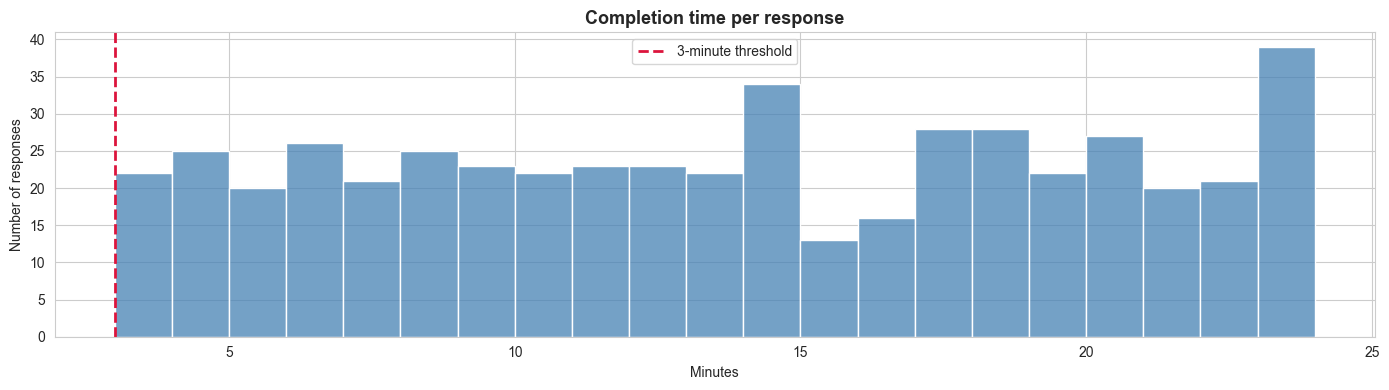

In [23]:
plt.figure(figsize=(14, 4))

# binwidth=1 instead of a fixed bin count: the duration is measured in whole
# minutes, so any other binning produces uneven bars and phantom gaps.
sns.histplot(data['duration_minutes'], binwidth=1, color='steelblue')

plt.axvline(3, color='crimson', linestyle='--', linewidth=2, label='3-minute threshold')
plt.title('Completion time per response', fontsize=13, fontweight='bold')
plt.xlabel('Minutes')
plt.ylabel('Number of responses')
plt.legend()
plt.tight_layout()
plt.show()

# Note on this data set: the durations are uniformly distributed between 3 and
# 24 minutes and the minimum sits exactly on the threshold. Real completion
# times are right-skewed, so this shape - and the resulting count of zero
# speeders - is a property of the generator, not a quality finding.


In [24]:
# 3. Straightlining
# Respondents who tick the same answer for every item produce a within-person
# standard deviation of (almost) zero across all 54 items.
data['answer_std'] = data[cols_to_recode].std(axis=1)

straightliner = data['answer_std'] < 0.25
print(f'Straightliners (within-person std < 0.25): {straightliner.sum()}')
print(data['answer_std'].describe().round(2))


Straightliners (within-person std < 0.25): 0
count    500.00
mean       0.87
std        0.18
min        0.41
25%        0.75
50%        0.86
75%        0.99
max        1.48
Name: answer_std, dtype: float64


In [25]:
# Overall verdict: how much of the data set is conspicuous?
conspicuous = speeder | straightliner
print(f'Conspicuous responses: {conspicuous.sum()} of {len(data)} '
      f'({conspicuous.mean() * 100:.1f} %)')

# Kept in the data set for now - flagged, not deleted, so the decision stays
# visible and reversible.
data['quality_flag'] = conspicuous


Conspicuous responses: 0 of 500 (0.0 %)


> **Findings:** see [findings.md - 3. Data quality](findings.md#3-data-quality)


---

### Sort Columns by Topic

---


In [26]:
# Thematic Groups

# Organizational Data
orga = [
    "organisation",
    "bereich",
    "iteration_id",
    "run_id",
    "abteilungs_id"
]

# Teamwork & Collaboration
team = [
    "team_effizienz",
    "zusammenarbeit_team",
    "zusammenarbeit_schnittstellen",
    "effizienz_schnittstellen",
    "hilfe_bitten",
    "teamstimmung"
]

# Psychological Safety & Culture
kultur = [
    "psychologische_sicherheit",
    "fehlerkultur_keine_vorwuerfe",
    "fehlerkultur_massnahmen",
    "meinungsfreiheit",
    "respekt",
    "offene_kommunikation",
    "kulturentwicklung_richtung"
]

# Leadership & Communication
fuehrung = [
    "info_fuehrung_veraenderung",
    "ehrlichkeit_fuehrung",
    "einbeziehung_fuehrung",
    "veraenderung_nachvollziehbar",
    "veraenderung_vorantreiben",
    "rahmenbedingungen_change"
]

# Strategy & Business
# Note: 'strategie_einfluss' ("the strategy influences my work decisions")
# measures salience rather than satisfaction - high agreement is not
# unambiguously positive. It is kept in the score but flagged in findings.md.
strategie = [
    "businessentscheidungen_richtung",
    "strategie_einfluss",
    "strategieklarheit",
    "zielbeitrag_strategie",
    "info_geschaeftslage",
    "beitrag_wettbewerbsfaehigkeit"
]

# Work Structure & Responsibility
arbeitsgestaltung = [
    "gestaltungsspielraum",
    "eigenverantwortung_entscheidungen",
    "entscheidungsgeschwindigkeit",
    "erwartungsklarheit",
    "klare_ziele",
    "verantwortung_foerderung",
    "einfluss_arbeitsmenge",
    "arbeitsinformationen"
]

# Development & Learning
entwicklung = [
    "staerken_nutzen",
    "weiterentwicklung_foerderung",
    "anforderung_faehigkeit_match",
    "feedback_nutzen",
    "neues_lernen",
    "anspruchsvolle_aufgaben",
    "faehigkeiten_ausbau"
]

# Customer, Product & Process Focus
wertschoepfung = [
    "produktgestaltung_aktiv",
    "kundenfokus",
    "beitrag_kundennutzen",
    "prozessverbesserung_kontinuierlich",
    "prozesse_hinterfragen",
    "externe_impulse",
    "tools_technologien",
    "neue_ideen_ausprobieren",
    "veraenderung_aktiv"
]

# Engagement & Wellbeing
# 'ueberlastung_r' is reverse coded: high value = low workload (see above)
engagement = [
    "lob_anerkennung",
    "arbeitgeber_empfehlung",
    "arbeitsfreude",
    "work_life_balance",
    "ueberlastung_r"
]

# Free Text
freitext = [
    "freitext_kommentar"
]


In [27]:
# Control: do the eight groups cover every Likert item exactly once?
grouped_items = team + kultur + fuehrung + strategie + arbeitsgestaltung + entwicklung + wertschoepfung + engagement

assert len(grouped_items) == len(set(grouped_items)), 'An item appears in more than one group'
unassigned = set(cols_to_recode) - set(grouped_items)
assert not unassigned, f'Items missing from every group: {unassigned}'

print(f'{len(grouped_items)} of {len(cols_to_recode)} Likert items assigned to a topic group')


54 of 54 Likert items assigned to a topic group


In [28]:
# A dictionary containing all categories (except Orga and Freitext)
categories_dict = {
    "Teamarbeit": team,
    "Kultur": kultur,
    "Führung": fuehrung,
    "Strategie": strategie,
    "Arbeitsgestaltung": arbeitsgestaltung,
    "Entwicklung": entwicklung,
    "Wertschöpfung": wertschoepfung,
    "Engagement": engagement
}


---

## Reliability of the Topic Scales

---

Before averaging several items into one score, it is worth checking that those
items actually measure the same thing. Cronbach's alpha quantifies that internal
consistency. Rule of thumb: `>= 0.7` acceptable, `>= 0.8` good, `< 0.6`
questionable. A value close to `1.0` is not a bonus - it usually means the items
are paraphrases of each other rather than facets of one construct.


In [29]:
def cronbach_alpha(items: pd.DataFrame) -> float:
    """Internal consistency of a set of items, on complete cases only."""
    items = items.dropna()
    k = items.shape[1]
    item_variances = items.var(axis=0, ddof=1).sum()
    total_variance = items.sum(axis=1).var(ddof=1)
    return k / (k - 1) * (1 - item_variances / total_variance)


reliability = pd.DataFrame([
    {
        'topic': name,
        'n_items': len(item_columns),
        'n_complete_cases': data[item_columns].dropna().shape[0],
        'cronbach_alpha': round(cronbach_alpha(data[item_columns]), 2),
    }
    for name, item_columns in categories_dict.items()
]).sort_values('cronbach_alpha', ascending=False)

display(reliability)


,topic,n_items,n_complete_cases,cronbach_alpha
0,Teamarbeit,6,422,0.95
1,Kultur,7,391,0.84
5,Entwicklung,7,387,0.84
4,Arbeitsgestaltung,8,378,0.83
6,Wertschöpfung,9,349,0.83
3,Strategie,6,403,0.80
2,Führung,6,387,0.73
7,Engagement,5,420,0.70


---

## Ratings by Topic Group

---


In [30]:
# Calculate mean values across all categories (row-wise first)
topic_means = {}
for name, item_columns in categories_dict.items():
    # Mean per row (person), then mean across all persons.
    # axis=1 means: calculate mean across columns for each row
    topic_means[name] = data[item_columns].mean(axis=1).mean()

# Convert to a DataFrame and sort in descending order
df_topics = pd.DataFrame(
    list(topic_means.items()),
    columns=['topic', 'average_value']
).sort_values(by='average_value', ascending=False)

print("--- TOPIC OVERVIEW (from highest to lowest mean value) ---")
display(df_topics)


--- TOPIC OVERVIEW (from highest to lowest mean value) ---


,topic,average_value
7,Engagement,3.528500
0,Teamarbeit,3.509733
1,Kultur,3.437086
2,Führung,3.412767
5,Entwicklung,3.319229
6,Wertschöpfung,3.289587
3,Strategie,3.232333
4,Arbeitsgestaltung,3.150436


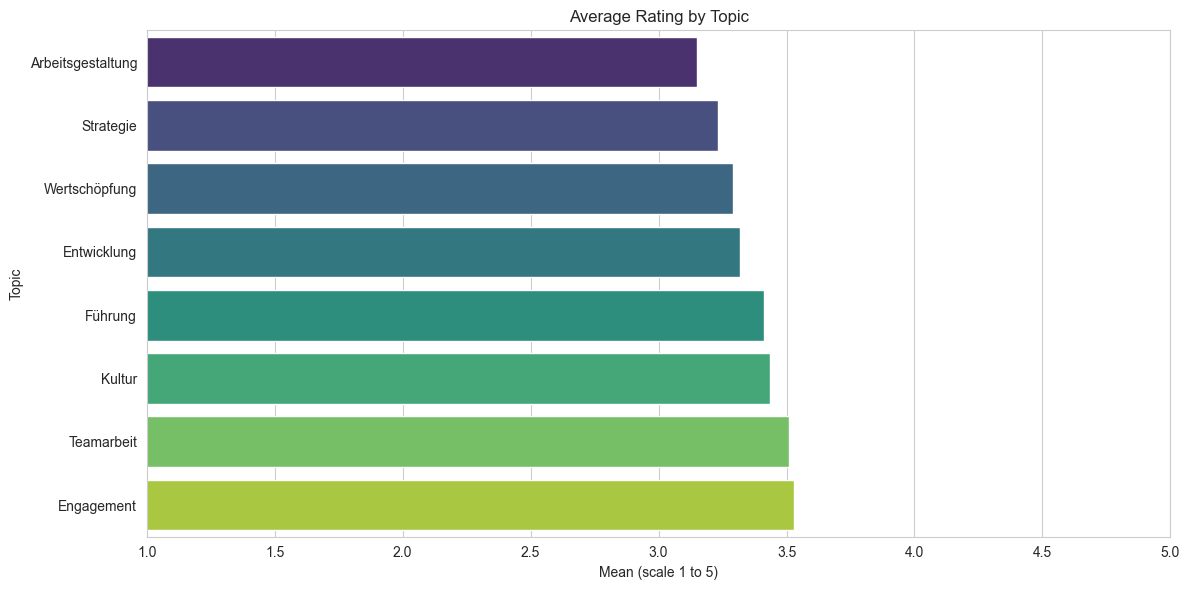

In [31]:
# Sort ascending so the highest value ends up at the top of the chart
df_plot = df_topics.sort_values(by='average_value', ascending=True)

plt.figure(figsize=(12, 6))
sns.barplot(x='average_value', y='topic', data=df_plot,
            hue='topic', palette='viridis', legend=False)

plt.title('Average Rating by Topic')
plt.xlabel('Mean (scale 1 to 5)')
plt.ylabel('Topic')

plt.xlim(1, 5)  # Fix the scale from 1 to 5
plt.tight_layout()
plt.show()


In [32]:
# Dictionary to store statistical metrics for each topic
topic_stats = {}

for name, item_columns in categories_dict.items():
    # Average rating per respondent (row) for the current category
    row_means = data[item_columns].mean(axis=1)

    topic_stats[name] = {
        'average_value': row_means.mean(),
        'std': row_means.std(),
        'min': row_means.min(),
        'max': row_means.max(),
        'n_respondents': row_means.notnull().sum()
    }

df_topic_stats = pd.DataFrame(topic_stats).T.sort_values('average_value', ascending=True)
display(df_topic_stats.round(2))


,average_value,std,min,max,n_respondents
Arbeitsgestaltung,3.15,0.70,1.25,4.86,500.0
Strategie,3.23,0.72,1.17,4.83,500.0
Wertschöpfung,3.29,0.67,1.22,4.89,500.0
Entwicklung,3.32,0.71,1.33,4.86,500.0
Führung,3.41,0.65,1.33,4.83,500.0
Kultur,3.44,0.74,1.33,5.00,500.0
Teamarbeit,3.51,0.92,1.00,5.00,500.0
Engagement,3.53,0.65,1.40,5.00,500.0


In [33]:
# Save the topic scores for later analysis (correlation, group comparison, modeling)
score_cols = []
for name, item_columns in categories_dict.items():
    clean_name = (
        name.lower()
        .replace(" ", "_")
        .replace("ä", "ae")
        .replace("ö", "oe")
        .replace("ü", "ue")
    )
    data[f'{clean_name}_score'] = data[item_columns].mean(axis=1)
    score_cols.append(f'{clean_name}_score')

print(score_cols)


['teamarbeit_score', 'kultur_score', 'fuehrung_score', 'strategie_score', 'arbeitsgestaltung_score', 'entwicklung_score', 'wertschoepfung_score', 'engagement_score']


> **Findings:** see [findings.md - 4. Topic level and scale reliability](findings.md#4-topic-level-and-scale-reliability)


---

## Ratings by Business Unit (Bereich)

---

`bereich` is the only real business dimension in the data set (5 units, 82-114
respondents each). This is the breakdown stakeholders will ask for first.

'bereich' was intentionally chosen as the sole business dimension to comply with
data protection (GDPR) and works council regulations...



In [34]:
# Mean topic score per business unit
scores_by_unit = data.groupby('bereich')[score_cols].mean()
display(scores_by_unit.round(2))


,teamarbeit_score,kultur_score,fuehrung_score,strategie_score,arbeitsgestaltung_score,entwicklung_score,wertschoepfung_score,engagement_score
bereich,,,,,,,,
FO-GA (Fokusbereich Gamma),3.55,3.46,3.43,3.28,3.25,3.31,3.28,3.62
IN-AL (Innovationsfeld Alpha),3.52,3.36,3.37,3.13,3.19,3.25,3.25,3.48
KE-EP (Kernbereich Epsilon),3.52,3.53,3.43,3.32,3.14,3.31,3.32,3.56
TR-DE (Transformationsfeld Delta),3.38,3.39,3.45,3.22,3.07,3.35,3.32,3.45
ZU-BE (Zukunftssegment Beta),3.58,3.47,3.41,3.24,3.12,3.38,3.28,3.57


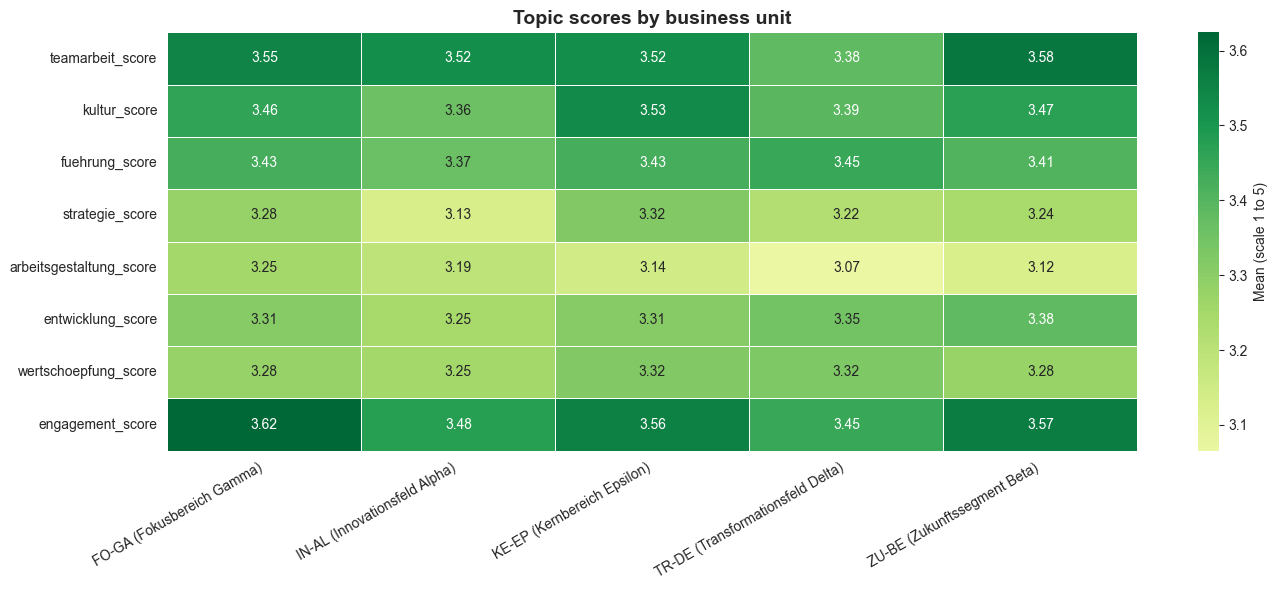

In [35]:
plt.figure(figsize=(14, 6))
sns.heatmap(
    scores_by_unit.T,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=3,
    linewidths=0.5,
    cbar_kws={'label': 'Mean (scale 1 to 5)'},
)
plt.title('Topic scores by business unit', fontsize=14, fontweight='bold')
plt.xlabel('')
plt.ylabel('')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


In [36]:
# Which topic separates the units most? A large spread means the topic is a
# local problem; a small spread means it is an organisation-wide pattern.
spread = (scores_by_unit.max() - scores_by_unit.min()).sort_values(ascending=False)
print('--- Spread between the strongest and the weakest unit ---')
print(spread.round(2))


--- Spread between the strongest and the weakest unit ---
teamarbeit_score           0.20
strategie_score            0.19
arbeitsgestaltung_score    0.18
engagement_score           0.18
kultur_score               0.18
entwicklung_score          0.14
fuehrung_score             0.08
wertschoepfung_score       0.07
dtype: float64


> **Findings:** see [findings.md - 5. Differences between business units](findings.md#5-differences-between-business-units)


---

## Correlations

---


### By Topic Group

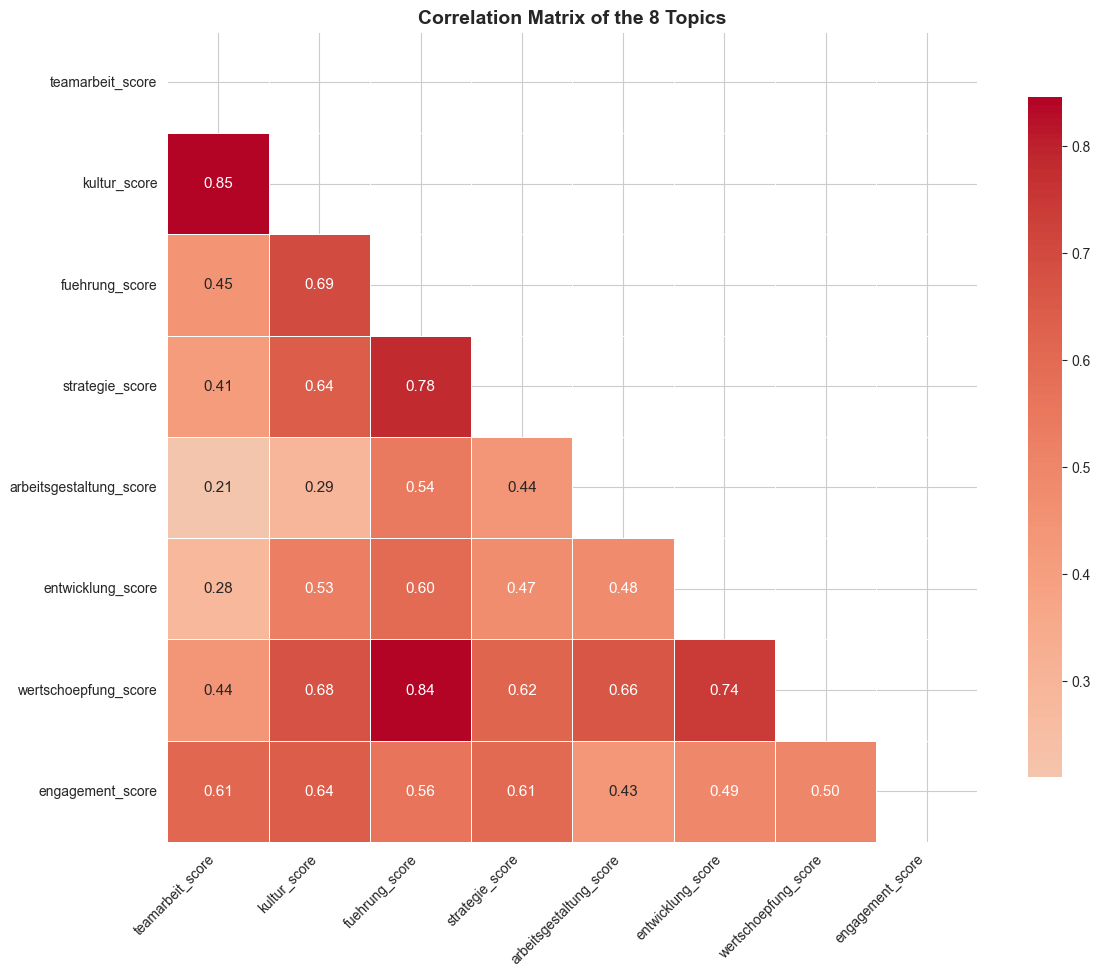

,teamarbeit_score,kultur_score,fuehrung_score,strategie_score,arbeitsgestaltung_score,entwicklung_score,wertschoepfung_score,engagement_score
teamarbeit_score,1.00,0.85,0.45,0.41,0.21,0.28,0.44,0.61
kultur_score,0.85,1.00,0.69,0.64,0.29,0.53,0.68,0.64
fuehrung_score,0.45,0.69,1.00,0.78,0.54,0.60,0.84,0.56
strategie_score,0.41,0.64,0.78,1.00,0.44,0.47,0.62,0.61
arbeitsgestaltung_score,0.21,0.29,0.54,0.44,1.00,0.48,0.66,0.43
entwicklung_score,0.28,0.53,0.60,0.47,0.48,1.00,0.74,0.49
wertschoepfung_score,0.44,0.68,0.84,0.62,0.66,0.74,1.00,0.50
engagement_score,0.61,0.64,0.56,0.61,0.43,0.49,0.50,1.00


In [37]:
# Correlation matrix of the eight topic scores
corr_matrix = data[score_cols].corr()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Upper triangle mask

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    annot_kws={'fontsize': 11}
)

plt.title('Correlation Matrix of the 8 Topics', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

display(corr_matrix.round(2))


> **Findings:** see [findings.md - 6. Correlations between topics](findings.md#6-correlations-between-topics)


#### Correlation Strength according to Cohen (1988)

| Correlation (r) | Strength | Interpretation |
| :--- | :--- | :--- |
| 0.00 - 0.09 | Very weak | No relevant relationship |
| 0.10 - 0.29 | Weak | Slight relationship |
| 0.30 - 0.49 | Moderate | Moderate relationship |
| 0.50 - 0.79 | Strong | Strong relationship |
| 0.80 - 1.00 | Very strong | Very strong relationship |


### By Item

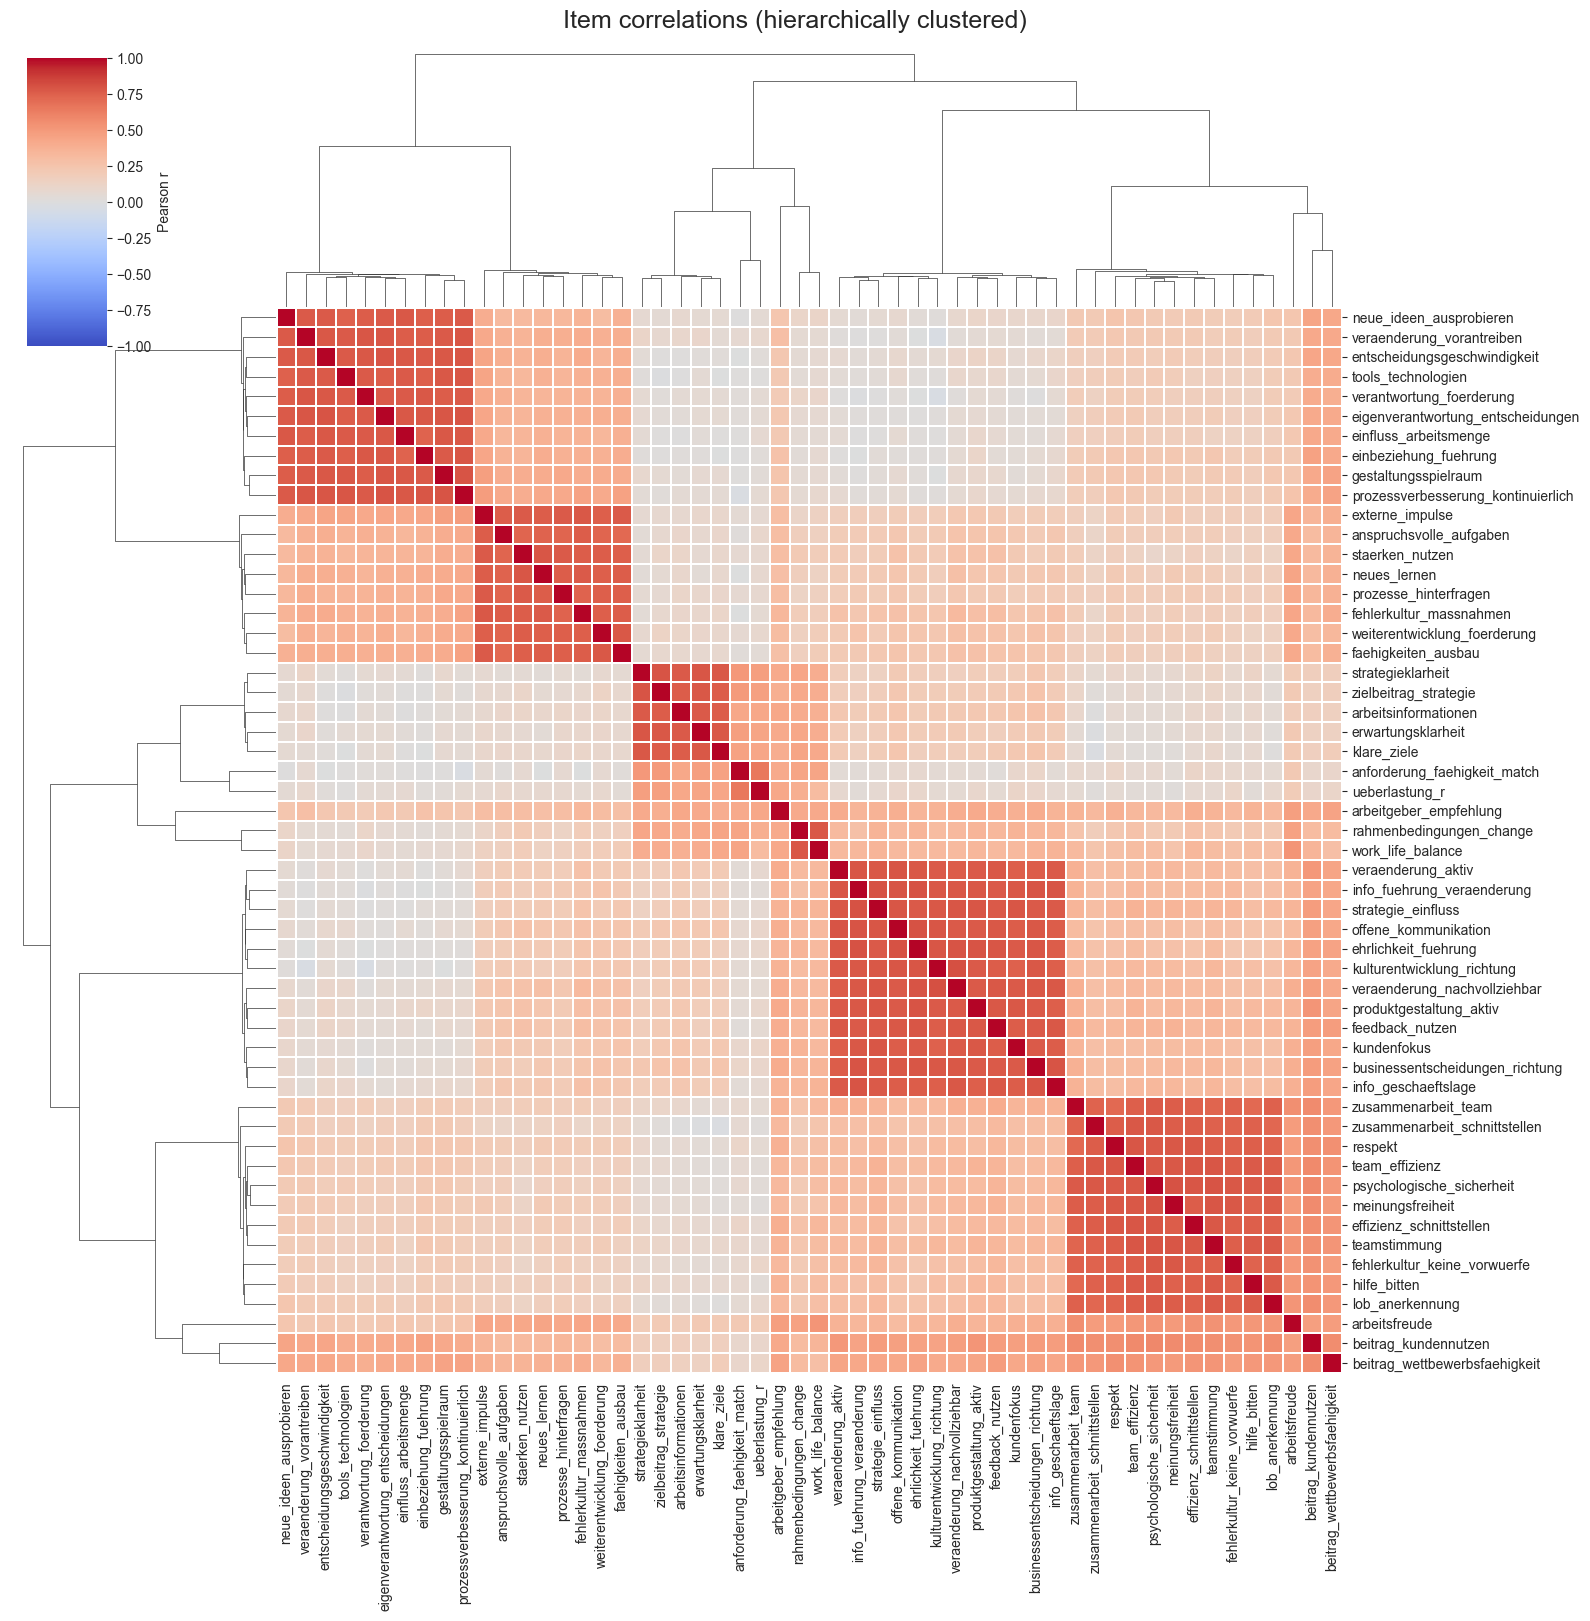

In [38]:
# Correlation of all 54 items.
# A plain 54x54 heatmap is unreadable, so the clustermap reorders rows and
# columns by similarity: blocks of related items become visible and can be
# compared against the thematic grouping defined above.
cols_likert = cols_to_recode
item_correlations = data[cols_likert].corr()

g = sns.clustermap(
    item_correlations,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    figsize=(16, 16),
    linewidths=0.2,
    cbar_kws={'label': 'Pearson r'},
)
g.figure.suptitle('Item correlations (hierarchically clustered)',
                  fontsize=18, y=1.01)
plt.show()


> **Findings:** see [findings.md - 7. Item-level structure](findings.md#7-item-level-structure)


---

## Distribution check of the Likert scales (diverging bar chart)

---

To see whether answers polarise or cluster on the neutral middle ("Teils/Teils",
value 3), we look at the percentage distribution of the categories across all
Likert columns.


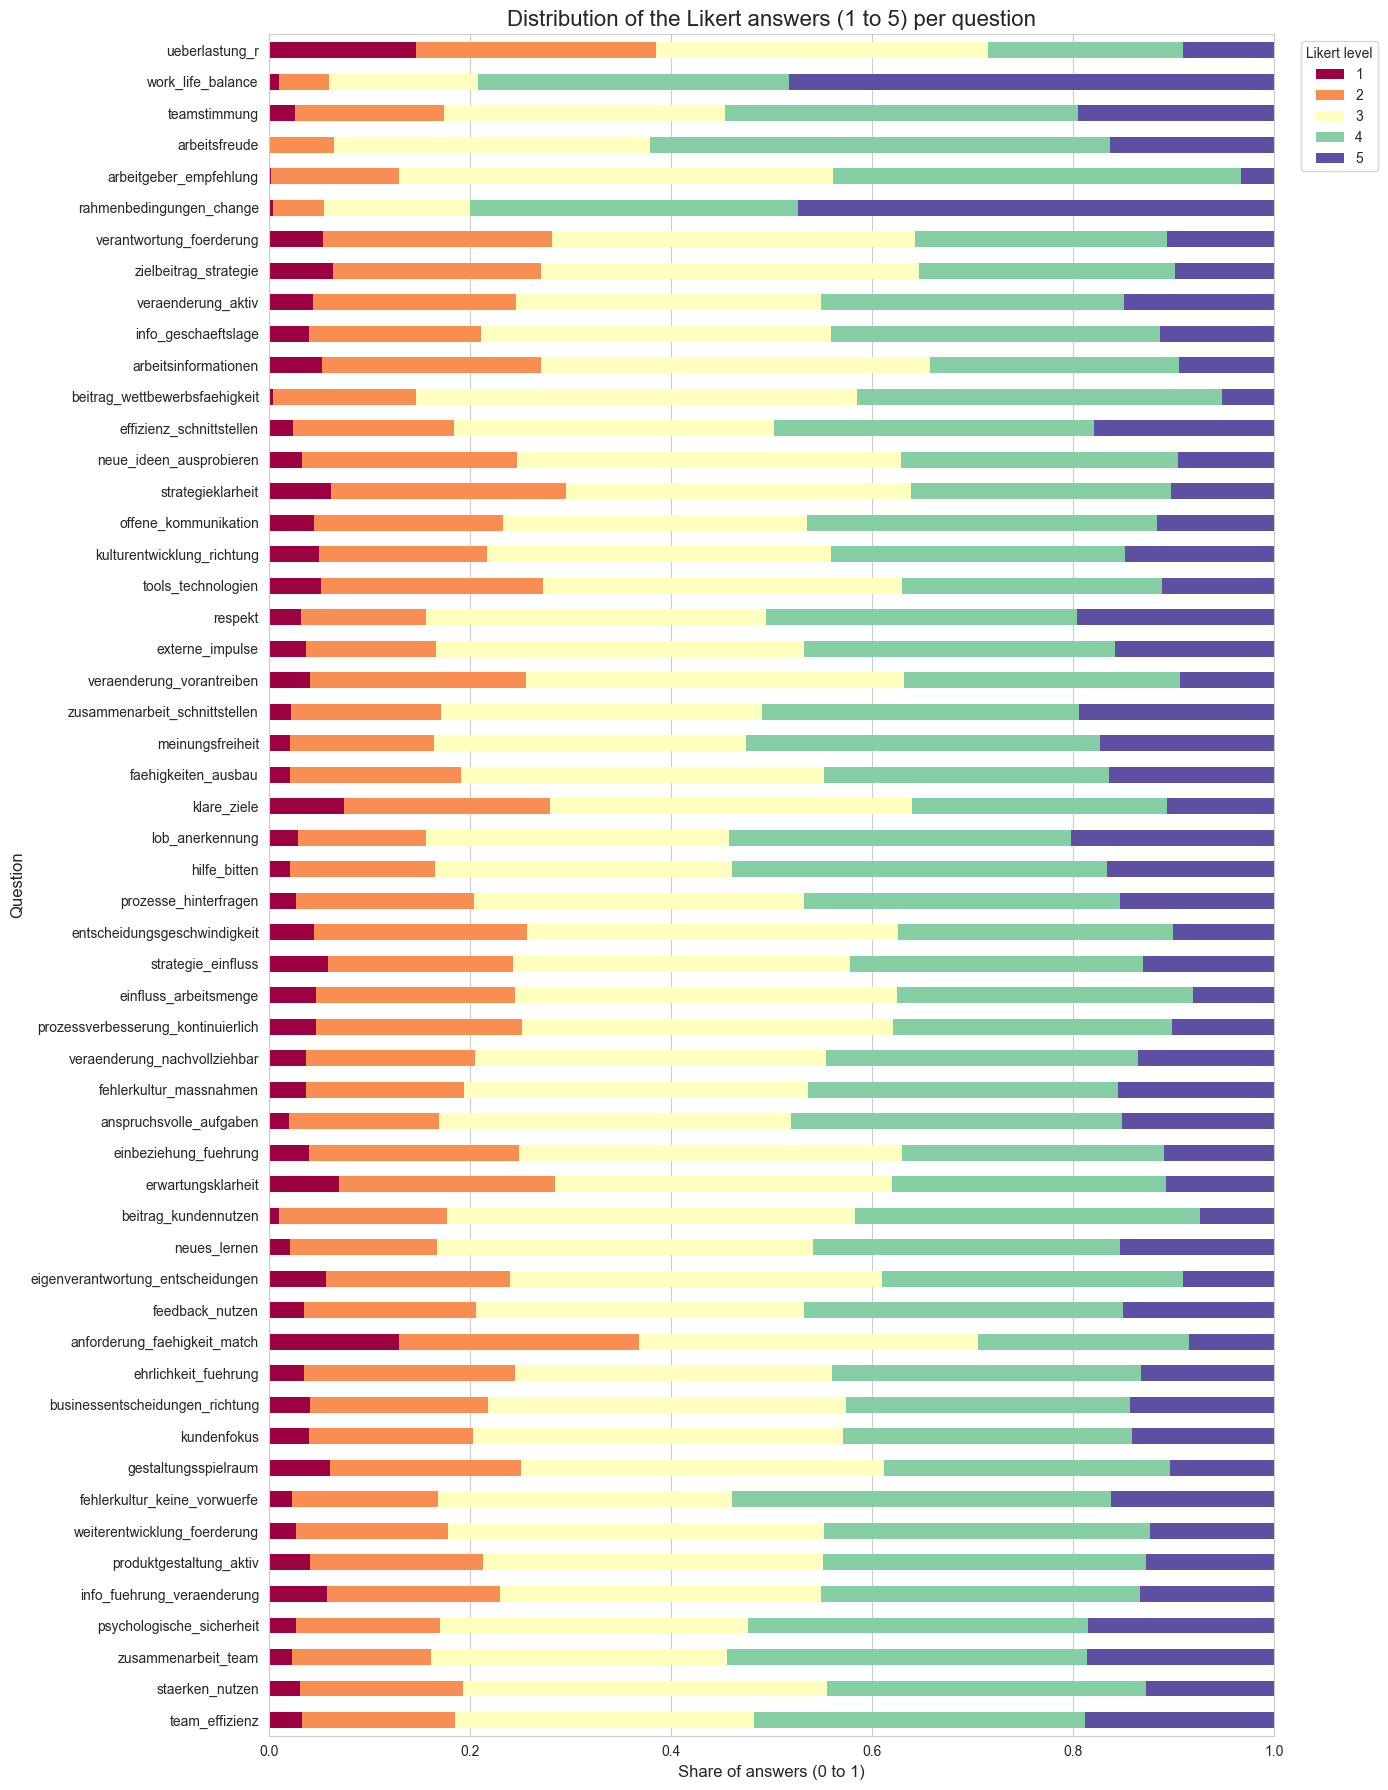

In [39]:
# Percentage distribution (1.0 to 5.0) for each Likert column
distribution_df = data[cols_likert].apply(lambda x: x.value_counts(normalize=True)).T.fillna(0)

# Make sure the columns 1 to 5 are present and in the right order
for i in [1.0, 2.0, 3.0, 4.0, 5.0]:
    if i not in distribution_df.columns:
        distribution_df[i] = 0.0
distribution_df = distribution_df[[1.0, 2.0, 3.0, 4.0, 5.0]]
distribution_df.columns = ['1', '2', '3', '4', '5']

# Stacked bar chart across all questions
ax = distribution_df.plot(kind='barh', stacked=True, colormap='Spectral',
                        edgecolor='none', figsize=(14, 18))

plt.title('Distribution of the Likert answers (1 to 5) per question', fontsize=16)
plt.xlabel('Share of answers (0 to 1)', fontsize=12)
plt.ylabel('Question', fontsize=12)
plt.legend(title='Likert level', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xlim(0, 1)
plt.tight_layout()
plt.show()


---

# Exploratory Data Analysis on Qualitative Feedback

---


---

### Who leaves a comment?

---

Sentiment analysis will only ever see the people who chose to write something.
If those people rate the survey differently from the silent majority, every later
sentiment statement describes a self-selected group - a bias that has to be named
explicitly rather than discovered afterwards.


In [40]:
# Comment rate per business unit
comment_rate = (
    data.groupby('bereich')['has_comment']
    .agg(with_comment='sum', n='count', share='mean')
)
comment_rate['share_%'] = (comment_rate.pop('share') * 100).round(1)
display(comment_rate)


,with_comment,n,share_%
bereich,,,
FO-GA (Fokusbereich Gamma),79,82,96.3
IN-AL (Innovationsfeld Alpha),109,114,95.6
KE-EP (Kernbereich Epsilon),87,90,96.7
TR-DE (Transformationsfeld Delta),104,108,96.3
ZU-BE (Zukunftssegment Beta),103,106,97.2


In [41]:
# Do commenters rate differently from non-commenters?
comparison = data.groupby('has_comment')[score_cols].mean().T
comparison.columns = ['without comment', 'with comment']
comparison['difference'] = comparison['with comment'] - comparison['without comment']
display(comparison.round(2).sort_values('difference'))


,without comment,with comment,difference
arbeitsgestaltung_score,3.50,3.14,-0.36
teamarbeit_score,3.80,3.50,-0.30
wertschoepfung_score,3.57,3.28,-0.29
fuehrung_score,3.55,3.41,-0.14
engagement_score,3.65,3.52,-0.13
kultur_score,3.51,3.43,-0.07
strategie_score,3.28,3.23,-0.05
entwicklung_score,3.32,3.32,-0.00


---

## Reading the comments

---

The single most important EDA step for an NLP project: actually read the texts.
Everything downstream - preprocessing, choice of sentiment model, emotion
taxonomy - depends on what the answers really look like.


In [42]:
# Random but reproducible sample of ten comments
for i, text in enumerate(
    data.loc[data['has_comment'], 'freitext_kommentar'].sample(10, random_state=42), 1
):
    print(f'--- {i} ---')
    print(text)
    print()


--- 1 ---
Die neue Struktur ergibt für mich Sinn, endlich sind Zuständigkeiten klar. Danke, dass überhaupt gefragt wird.

--- 2 ---
Technisch hat sich viel verbessert, die Prozesse drumherum sind weiter zäh.

--- 3 ---
Ich bin da echt hin- und hergerissen. Geld ist nicht alles, ganz egal ist es mir aber auch nicht. Was mich stört: Seit den letzten Abgängen fehlt uns die gemeinsame Basis.

--- 4 ---
Ehrlich, ich kann nicht mehr. Neue Kolleginnen verdienen mehr als ich nach acht Jahren. Außerdem: Nach fünfzehn Jahren fühlt man sich hier ziemlich austauschbar.

--- 5 ---
Wenn jemand ausfäll, fäng tdas Team das ohne Diskussion auf!!! :)

--- 6 ---
Auf mein Team kann ich mich hundertprozentig verlassen, das trägt mich durch vieles.

--- 7 ---
Ich schaffe meine Aufgaben in der regulären Zeit und das tut gut.

--- 8 ---
Ich hatte mehr erwartet. Konflikte werden bei uns ausgesessen statt angesprochen. Kritik wird angehört, geändert wird danach nichts.

--- 9 ---
Ich hoffe wirklich, dass das so

---

## Counts and Length

---

How long are the comments?
* Character count
* Word count
* Mean word length
* Mean sentence length


In [43]:
sample_length = len(data['freitext_kommentar'].iloc[0])
print(f'Length of a sample feedback: {sample_length}')


Length of a sample feedback: 123


In [44]:
data['length'] = data['freitext_kommentar'].str.len()
data[['freitext_kommentar', 'length']].head(10)


,freitext_kommentar,length
0,"Ehrlich gesagt: Ich weiß genau, woran ich arbe...",123
1,Bringt ja eh nichts. Wissen hängt bei uns an e...,83
2,"Ich finde die Richtung richtig, auch wenn der ...",146
3,"Ehrlich, ich kann nicht mehr. Konflikte werden...",222
4,Aus meiner Sicht: Die neue Struktur ergibt für...,388
5,Ich hatte mehr erwaret. In meinen ersten Woche...,148
6,Ich mache mir Sorgen. Entwicklungsgespräche si...,465
7,Vielleicht wird es ja gerade besser. Dass wir ...,242
8,Die letzte Gehaltsrunde war fair und nachvollz...,138
9,"vielen dank dafür: ich merke, das meine erfahr...",64


In [45]:
# Only responses that actually contain a comment
data.loc[data['has_comment'], 'length'].describe().round(1)


count    482.0
mean     183.2
std      100.9
min       31.0
25%      105.0
50%      161.5
75%      234.0
max      608.0
Name: length, dtype: float64

---

## Word Count: Number of Words in a Feedback

---

In [46]:
sample_words = data['freitext_kommentar'].iloc[0].split()
print(f'Word count in a sample review: {len(sample_words)}')


Word count in a sample review: 19


In [47]:
def word_count(feedback):
    feedback_list = feedback.split()
    return len(feedback_list)


In [48]:
data['word_count'] = data['freitext_kommentar'].apply(word_count)
data[['freitext_kommentar', 'length', 'word_count']].head(10)


,freitext_kommentar,length,word_count
0,"Ehrlich gesagt: Ich weiß genau, woran ich arbe...",123,19
1,Bringt ja eh nichts. Wissen hängt bei uns an e...,83,14
2,"Ich finde die Richtung richtig, auch wenn der ...",146,22
3,"Ehrlich, ich kann nicht mehr. Konflikte werden...",222,32
4,Aus meiner Sicht: Die neue Struktur ergibt für...,388,62
5,Ich hatte mehr erwaret. In meinen ersten Woche...,148,25
6,Ich mache mir Sorgen. Entwicklungsgespräche si...,465,77
7,Vielleicht wird es ja gerade besser. Dass wir ...,242,37
8,Die letzte Gehaltsrunde war fair und nachvollz...,138,19
9,"vielen dank dafür: ich merke, das meine erfahr...",64,11


In [49]:
data.loc[data['has_comment'], 'word_count'].describe().round(1)


count    482.0
mean      29.2
std       16.2
min        6.0
25%       16.2
50%       25.0
75%       38.0
max       94.0
Name: word_count, dtype: float64

---

## Mean word length: Average length of words

---

In [50]:
# Empty comments (the 18 filled with "") have no words:
# return NaN explicitly instead of letting np.mean([]) warn
def mean_word_length(feedback):
    words = feedback.split()
    return np.mean([len(word) for word in words]) if words else np.nan


data['mean_word_length'] = data['freitext_kommentar'].map(mean_word_length)
data[['freitext_kommentar', 'length', 'word_count', 'mean_word_length']].head(10)


,freitext_kommentar,length,word_count,mean_word_length
0,"Ehrlich gesagt: Ich weiß genau, woran ich arbe...",123,19,5.526316
1,Bringt ja eh nichts. Wissen hängt bei uns an e...,83,14,5.000000
2,"Ich finde die Richtung richtig, auch wenn der ...",146,22,5.681818
3,"Ehrlich, ich kann nicht mehr. Konflikte werden...",222,32,5.968750
4,Aus meiner Sicht: Die neue Struktur ergibt für...,388,62,5.274194
5,Ich hatte mehr erwaret. In meinen ersten Woche...,148,25,4.960000
6,Ich mache mir Sorgen. Entwicklungsgespräche si...,465,77,5.051948
7,Vielleicht wird es ja gerade besser. Dass wir ...,242,37,5.567568
8,Die letzte Gehaltsrunde war fair und nachvollz...,138,19,6.315789
9,"vielen dank dafür: ich merke, das meine erfahr...",64,11,4.909091


---

## Mean sentence length: Average length of the sentences in the feedback

---

In [51]:
np.mean([
    len(sent)
    for sent in tokenize.sent_tokenize(data['freitext_kommentar'].iloc[0], language='german')
])


np.float64(61.0)

In [52]:
# mean_sent_length = average number of characters per sentence
def mean_sent_length(feedback):
    sentences = tokenize.sent_tokenize(feedback, language='german')
    return np.mean([len(sent) for sent in sentences]) if sentences else np.nan


data['mean_sent_length'] = data['freitext_kommentar'].map(mean_sent_length)
data[['freitext_kommentar', 'length', 'word_count',
      'mean_word_length', 'mean_sent_length']].head(10)


,freitext_kommentar,length,word_count,mean_word_length,mean_sent_length
0,"Ehrlich gesagt: Ich weiß genau, woran ich arbe...",123,19,5.526316,61.000000
1,Bringt ja eh nichts. Wissen hängt bei uns an e...,83,14,5.000000,41.000000
2,"Ich finde die Richtung richtig, auch wenn der ...",146,22,5.681818,72.500000
3,"Ehrlich, ich kann nicht mehr. Konflikte werden...",222,32,5.968750,54.750000
4,Aus meiner Sicht: Die neue Struktur ergibt für...,388,62,5.274194,76.800000
5,Ich hatte mehr erwaret. In meinen ersten Woche...,148,25,4.960000,48.666667
6,Ich mache mir Sorgen. Entwicklungsgespräche si...,465,77,5.051948,65.571429
7,Vielleicht wird es ja gerade besser. Dass wir ...,242,37,5.567568,59.750000
8,Die letzte Gehaltsrunde war fair und nachvollz...,138,19,6.315789,68.500000
9,"vielen dank dafür: ich merke, das meine erfahr...",64,11,4.909091,31.500000


---

## Distribution of the individual metrics (univariate analysis)

---

How do the values spread across all comments (e.g. is the word count skewed to
the right)?

* **Histograms with kernel density estimation (KDE):** show the distribution of
  `word_count` or `mean_word_length`.
* **Boxplots:** reveal outliers (extremely long or extremely short comments).


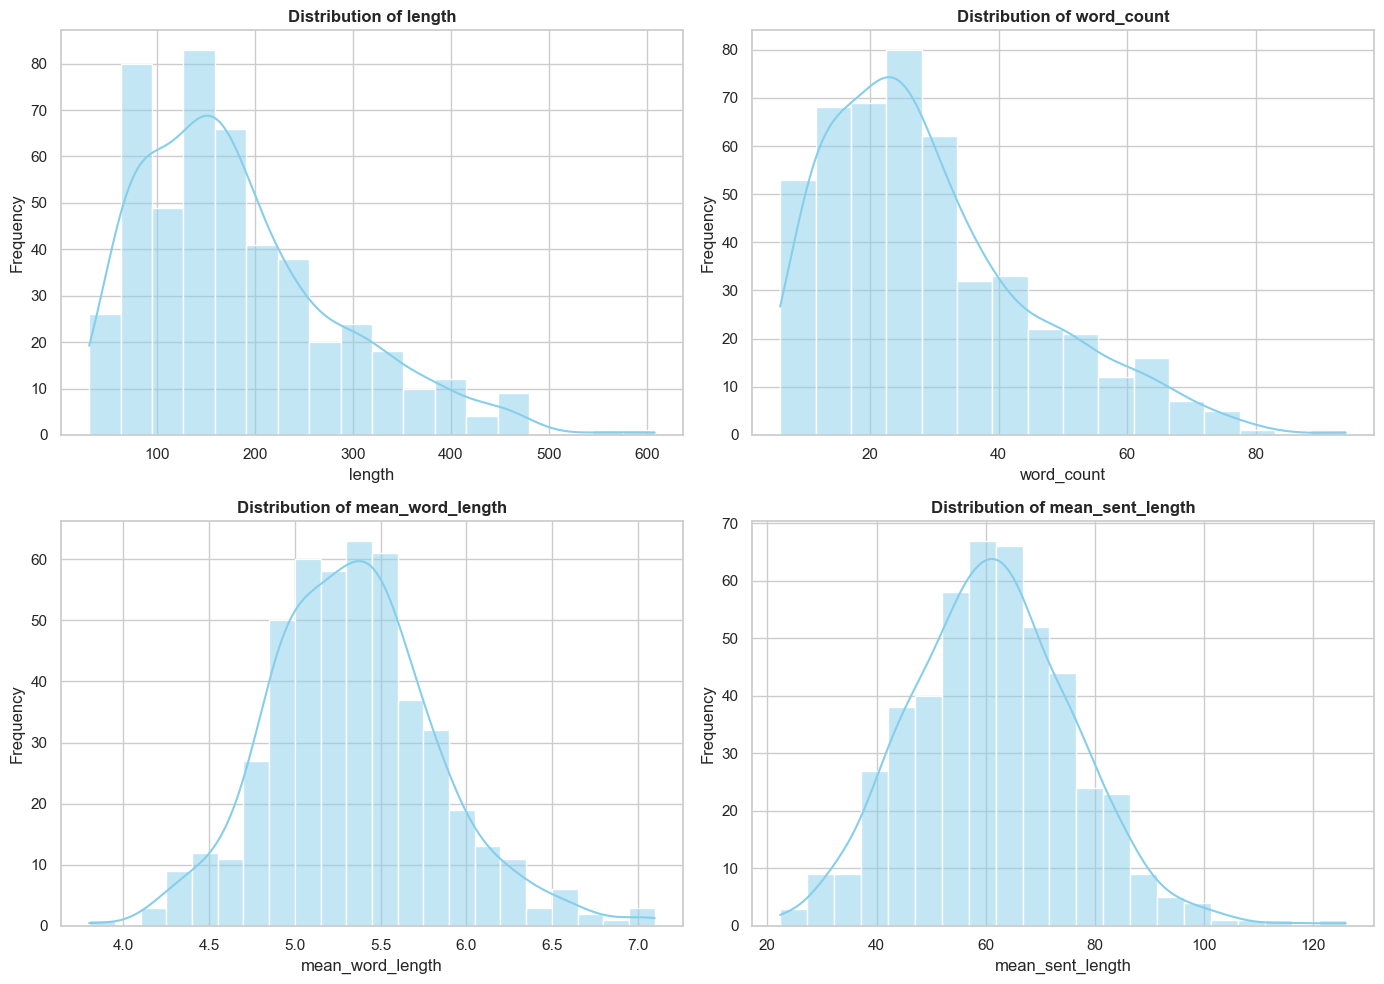

In [53]:
text_metrics = ['length', 'word_count', 'mean_word_length', 'mean_sent_length']

# Only responses that contain a comment - the 18 empty ones would produce a
# spike at zero and distort every distribution.
comments = data.loc[data['has_comment']]

sns.set_theme(style='whitegrid')

plt.figure(figsize=(14, 10))
for i, col in enumerate(text_metrics, 1):
    plt.subplot(2, 2, i)
    sns.histplot(data=comments, x=col, kde=True, color='skyblue')
    plt.title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


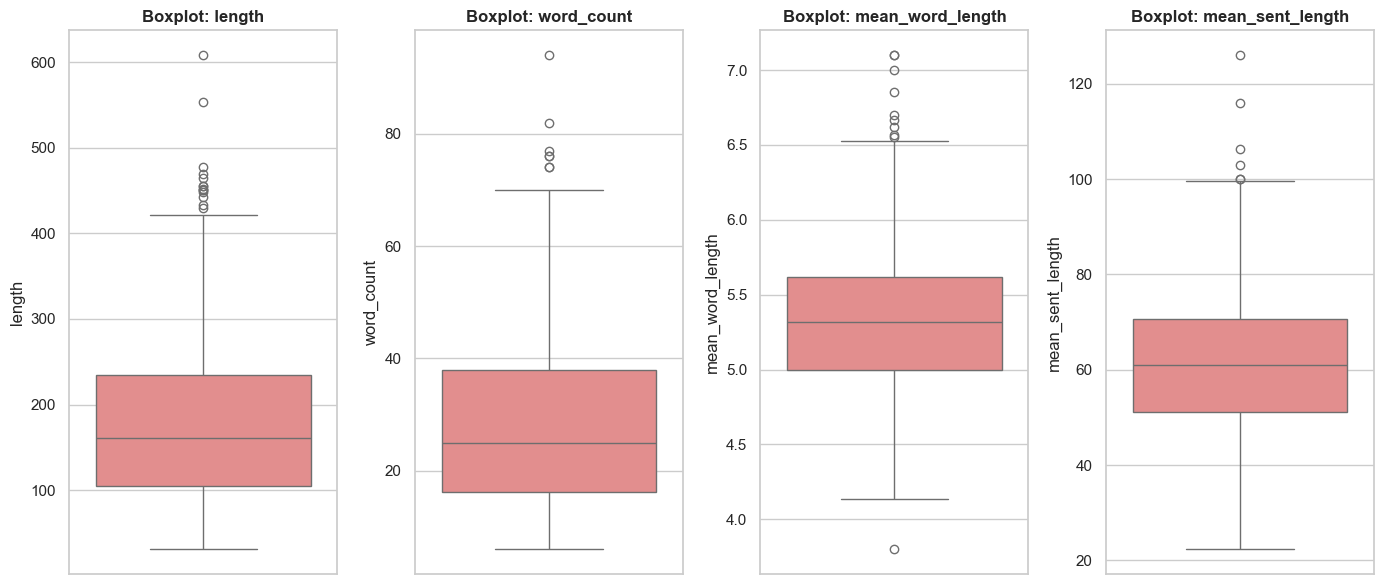

In [54]:
# Boxplots to detect outliers
plt.figure(figsize=(14, 6))
for i, col in enumerate(text_metrics, 1):
    plt.subplot(1, 4, i)
    sns.boxplot(y=comments[col], color='lightcoral')
    plt.title(f'Boxplot: {col}', fontsize=12, fontweight='bold')
    plt.ylabel(col)

plt.tight_layout()
plt.show()


---

## Relationships between the text features (bivariate analysis)

---

How do the metrics relate to each other?

* **Scatter plots:** `word_count` vs. `length` (a strong linear relationship is
  expected), and `mean_word_length` vs. `mean_sent_length` (do longer sentences
  also consist of longer words?).
* **Correlation heatmap:** all relationships at a glance.


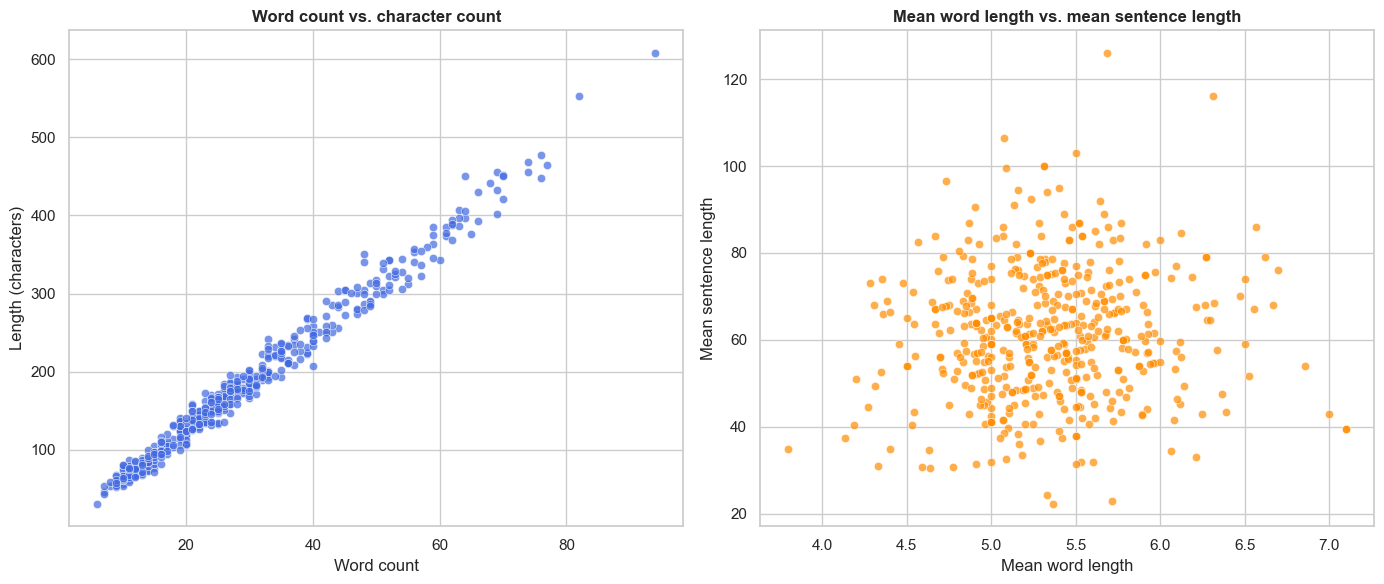

In [55]:
sns.set_theme(style='whitegrid')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.scatterplot(
    data=comments,
    x='word_count',
    y='length',
    ax=axes[0],
    color='royalblue',
    alpha=0.7,
)
axes[0].set_title('Word count vs. character count', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Word count')
axes[0].set_ylabel('Length (characters)')

sns.scatterplot(
    data=comments,
    x='mean_word_length',
    y='mean_sent_length',
    ax=axes[1],
    color='darkorange',
    alpha=0.7,
)
axes[1].set_title('Mean word length vs. mean sentence length', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Mean word length')
axes[1].set_ylabel('Mean sentence length')

plt.tight_layout()
plt.show()


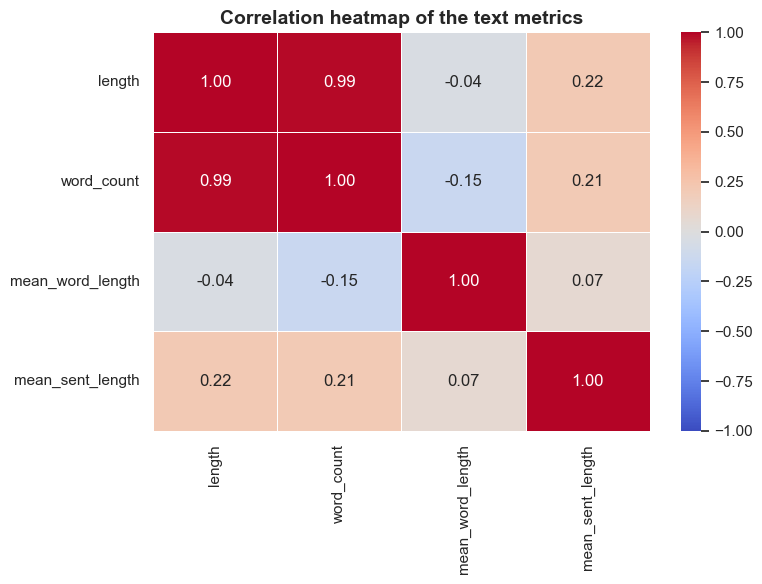

In [56]:
# Correlation heatmap of all text metrics
corr_text = comments[text_metrics].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_text,
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    fmt='.2f',
    linewidths=0.5,
)
plt.title('Correlation heatmap of the text metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---

## Text Content

---

Length tells us how much people wrote, not what they wrote. Before any sentiment
model is chosen we need to know which words dominate, whether the corpus contains
boilerplate non-answers, and how much genuinely analysable text there is.


In [57]:
# Very short comments are often non-answers ("nein", "-", "nichts").
print('--- 10 shortest comments ---')
for text in comments.nsmallest(10, 'length')['freitext_kommentar']:
    print(repr(text))

# Identical comments would point to copy-paste or template answers
print(f'\nIdentical comments: {comments["freitext_kommentar"].duplicated().sum()}')

# How many comments are too short to carry a sentiment?
too_short = comments['word_count'] < 3
print(f'Comments with fewer than 3 words: {too_short.sum()} '
      f'({too_short.mean() * 100:.1f} % of all comments)')


--- 10 shortest comments ---
'Lernen ja Zeit dafür eher nein.'
'Ich merke, dass meine Erfahrung hier zählt.'
'Ich funktioniere nur noch, statt zu arbeiten!!'
'Die Software kann viel, nur erklärt sie uns niemand.'
'Die Formate sind gut gedacht, nur leider viel zu lang.'
'Unsere Retros sind ehrlich und bringen wirklich etwas.'
'Die leetzte Gehaltsrunde war fair und nachvollziehbar.'
'In den großen Runden reden immer dieselben drei Leute.'
'Nach meiner Rückkehr wurde gut auf mein Tempo geachtet.'
'nach meiner rückkehr wurde gut auf mein tempo geachtet.'

Identical comments: 0
Comments with fewer than 3 words: 0 (0.0 % of all comments)


In [58]:
from nltk.corpus import stopwords

german_stopwords = stopwords.words('german')


def top_ngrams(texts, n, top=15):
    """Most frequent n-grams after removing German stopwords."""
    vectorizer = CountVectorizer(ngram_range=(n, n), stop_words=german_stopwords)
    matrix = vectorizer.fit_transform(texts)
    frequencies = np.asarray(matrix.sum(axis=0)).ravel()
    return (
        pd.Series(frequencies, index=vectorizer.get_feature_names_out())
        .sort_values(ascending=False)
        .head(top)
    )


for n, label in [(1, 'words'), (2, 'bigrams'), (3, 'trigrams')]:
    print(f'--- Top {label} ---')
    print(top_ngrams(comments['freitext_kommentar'], n))
    print()


--- Top words ---
gut         119
mal         104
kommt        94
mehr         78
zeit         73
finde        72
wirklich     69
team         66
niemand      65
neue         65
arbeit       60
außerdem     58
statt        57
richtig      52
wurde        51
dtype: int64

--- Top bigrams ---
neue kolleginnen             28
kolleginnen kollegen         23
mal loswerden                22
gleichzeitig gilt            22
treffen situation            19
situation teilweise          19
fragen treffen               19
arbeiten macht               19
unangenehme themen           17
benennt finde                17
gut vergisst                 17
zusatzleistungen wirklich    17
zeit genommen                17
themen benennt               17
finde stark                  17
dtype: int64

--- Top trigrams ---
fragen treffen situation          19
treffen situation teilweise       19
unangenehme themen benennt        17
gut vergisst leicht               17
wirklich gut vergisst             17
benennt 

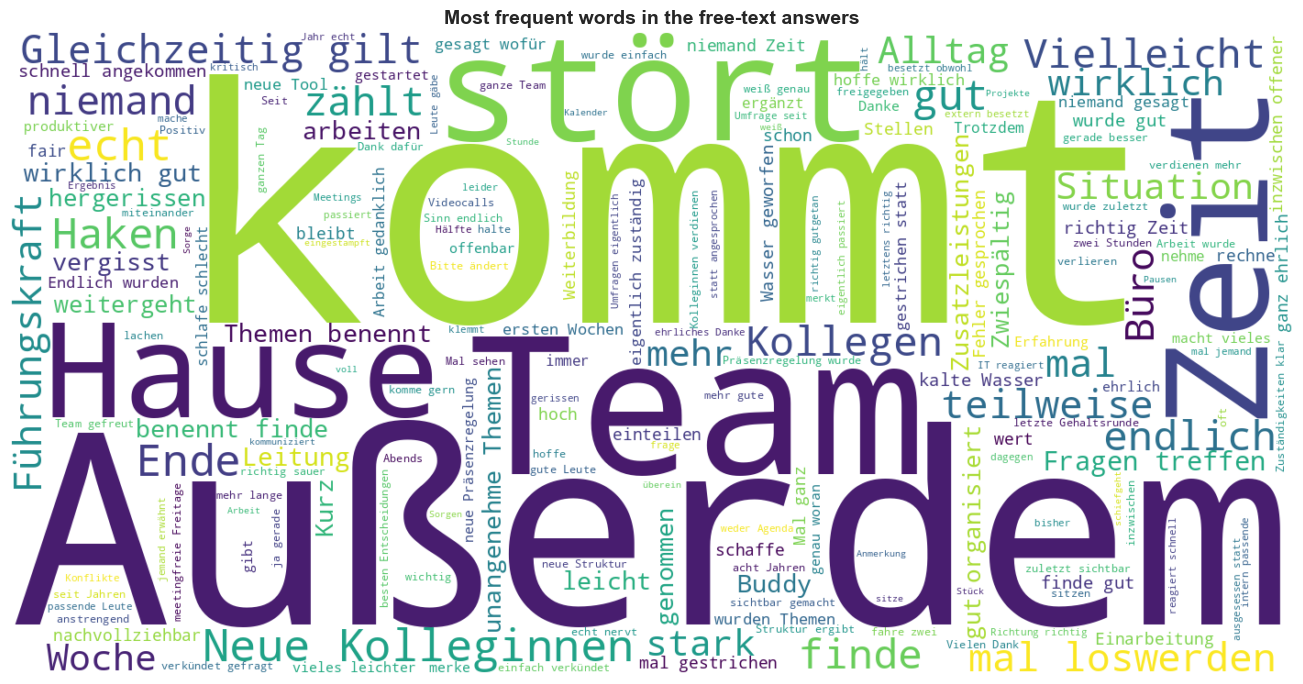

In [59]:
cloud = WordCloud(
    width=1400,
    height=700,
    background_color='white',
    stopwords=set(german_stopwords),
    colormap='viridis',
).generate(' '.join(comments['freitext_kommentar']))

plt.figure(figsize=(14, 7))
plt.imshow(cloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most frequent words in the free-text answers', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---

## Bridge: Text and Survey Scores

---

The link between the two halves of the data set - and the reason the free-text
answers are worth analysing at all. If comment length or the decision to comment
carries information about the ratings, the text is not just decoration.

In [60]:
# Overall satisfaction per respondent across all 54 items
data['overall_score'] = data[cols_to_recode].mean(axis=1)
comments = data.loc[data['has_comment']]

# How strongly do the text metrics relate to the topic scores?
bridge = (
    comments[text_metrics + score_cols + ['overall_score']]
    .corr()
    .loc[['word_count', 'length'], score_cols + ['overall_score']]
    .T
)
display(bridge.round(2).sort_values('word_count'))


,word_count,length
engagement_score,-0.13,-0.14
strategie_score,-0.09,-0.09
fuehrung_score,-0.08,-0.08
overall_score,-0.08,-0.09
teamarbeit_score,-0.07,-0.07
kultur_score,-0.07,-0.07
entwicklung_score,-0.06,-0.07
wertschoepfung_score,-0.05,-0.05
arbeitsgestaltung_score,-0.00,-0.00


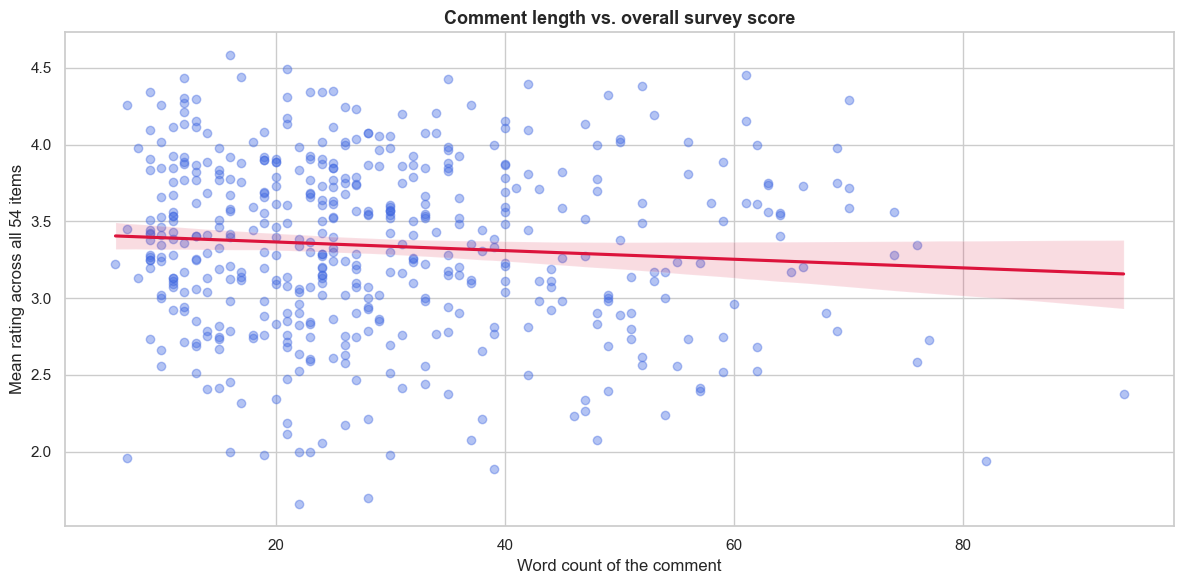

In [61]:
plt.figure(figsize=(12, 6))
sns.regplot(
    data=comments,
    x='word_count',
    y='overall_score',
    scatter_kws={'alpha': 0.4, 'color': 'royalblue'},
    line_kws={'color': 'crimson'},
)
plt.title('Comment length vs. overall survey score', fontsize=13, fontweight='bold')
plt.xlabel('Word count of the comment')
plt.ylabel('Mean rating across all 54 items')
plt.tight_layout()
plt.show()


> **Findings:** see [findings.md - 8. Free-text answers](findings.md#8-free-text-answers)


---

## Export & Limitations

---


In [62]:
# Write the cleaned data set so the preprocessing and modelling notebooks can
# start from here instead of repeating the cleaning.
from pathlib import Path

Path('data/processed').mkdir(parents=True, exist_ok=True)
data.to_csv('data/processed/survey_clean.csv', index=False)

print(f'Written: data/processed/survey_clean.csv  {data.shape[0]} rows x {data.shape[1]} columns')
print('\nDerived columns added by this notebook:')
print([c for c in data.columns if c not in df_raw.columns.str.strip()][-12:])


Written: data/processed/survey_clean.csv  500 rows x 81 columns

Derived columns added by this notebook:
['kultur_score', 'fuehrung_score', 'strategie_score', 'arbeitsgestaltung_score', 'entwicklung_score', 'wertschoepfung_score', 'engagement_score', 'length', 'word_count', 'mean_word_length', 'mean_sent_length', 'overall_score']


### Limitations

1. **Synthetic data.** These are generated dummy responses, not a real survey.
   Both the Likert distributions and the free texts follow the rules of the
   generator, so every substantive statement below is a statement about the
   generator - not about an organisation. The pipeline is what is being
   validated here, not the results.
2. **Free texts are generated.** The sentiment distribution of the comments does
   not represent how employees actually write. Any accuracy measured on this data
   would not transfer to production.
3. **Self-selection.** Only a subset of respondents leaves a comment. Sentiment
   results describe that subset, never the whole workforce.
4. **`abteilungs_id` is unusable for grouping in this data set** - it holds 500
   distinct random values for 500 rows. The department mapping can only be tested
   once real data is available.
5. **One wave only.** `iteration_id` is constant, so no development over time can
   be shown yet; `run_id` distinguishes four runs within the same wave.
